In [21]:
import numpy as np
import tensorflow as tf
import os
from tensorflow.keras.applications import VGG16

# Import datagen
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Sequential
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [2]:
tf.__version__

'2.19.0'

In [3]:
img_width, img_height = 150, 150

# nb_train_samples <=> number of train samples
nb_train_samples = 2000
nb_validation_samples = 800
epochs = 5
batch_size = 16

In [4]:
base_dir = "../data"

train_dir = os.path.join(base_dir, "train")
validation_dir = os.path.join(base_dir, "validation")

train_cats_dir = os.path.join(train_dir, "cats")
train_dogs_dir = os.path.join(train_dir, "dogs")

validation_cats_dir = os.path.join(validation_dir, "cats")
validation_dogs_dir = os.path.join(validation_dir, "dogs")

In [5]:
train_cat_frame = os.listdir(train_cats_dir)
train_dog_frame = os.listdir(train_dogs_dir)

validation_cat_frame = os.listdir(validation_cats_dir)
validation_dog_frame = os.listdir(validation_dogs_dir)

print(f"Total training cat images: {len(train_cat_frame)}")
print(f"Total training dog images: {len(train_dog_frame)}")
print(f"Total validation cat images: {len(validation_cat_frame)}")
print(f"Total validation dog images: {len(validation_dog_frame)}")

Total training cat images: 1000
Total training dog images: 1000
Total validation cat images: 504
Total validation dog images: 504


In [6]:
training_data_dir = train_dir
validation_data_dir = validation_dir
test_data_dir = validation_dir

In [ ]:
# include_top = False nghĩa là bỏ phần fully connected layer của VGG16, chỉ lấy phần convolutional layer thôi để trích xuất đặc trưng ảnh
model = VGG16(include_top=False, weights="imagenet")

In [ ]:
# Rescale=1.0 / 255 để đưa giá trị pixel về khoảng [0, 1
datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = datagen.flow_from_directory(
    training_data_dir,  # this is the target directory
    target_size=(img_width, img_height),  # all images will be resized to 150x150
    batch_size=batch_size,
    class_mode=None,  # Class_model=None
    shuffle=False,
)  # shuffle the data for better training

bottleneck_features_train = model.predict(train_generator, nb_train_samples // batch_size)

np.save(
    os.path.join(base_dir, "bottleneck_features_train.npy"), bottleneck_features_train
)

Found 2000 images belonging to 2 classes.


d:\School\4thYear\2ndSemester\AI\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


125/125 ━━━━━━━━━━━━━━━━━━━━ 80s 640ms/step


In [11]:
validation_generator = datagen.flow_from_directory(
    validation_data_dir,  # this is the target directory
    target_size=(img_width, img_height),  # all images will be resized to 150x150
    batch_size=batch_size,
    class_mode=None,  # Class_model=None
    shuffle=False,
)  #

bottleneck_features_validation = model.predict(
    validation_generator, nb_validation_samples // batch_size
)

np.save(
    os.path.join(base_dir, "bottleneck_features_validation.npy"),
    bottleneck_features_validation,
)

Found 1008 images belonging to 2 classes.


d:\School\4thYear\2ndSemester\AI\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 42s 673ms/step


In [ ]:
train_data = np.load(os.path.join(base_dir, "bottleneck_features_train.npy"))

# Nối 2 danh sách gồm 1000 ảnh mèo và 1000 ảnh chó thành 1 danh sách
train_labels = np.array([0] * 1000 + [1] * 1000)

validation_data = np.load(os.path.join(base_dir, "bottleneck_features_validation.npy"))
validation_labels = np.array([0] * 504 + [1] * 504)

# Xây dựng fully connected layer sau khi đã trích xuất đặc trưng ảnh bằng VGG16
model = Sequential()
model.add(Flatten(input_shape=train_data.shape[1:]))
model.add(Dense(256, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(1, activation="sigmoid"))
model.summary()

d:\School\4thYear\2ndSemester\AI\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,097,665 (8.00 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(optimizer="rmsprop", loss="binary_crossentropy", metrics=["accuracy"])

# Train the model
model.fit(
    train_data,
    train_labels,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(validation_data, validation_labels),
)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7004 - loss: 1.0896 - val_accuracy: 0.8244 - val_loss: 0.3654
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8444 - loss: 0.3374 - val_accuracy: 0.8948 - val_loss: 0.2704
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8883 - loss: 0.2605 - val_accuracy: 0.8938 - val_loss: 0.2772
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9079 - loss: 0.2279 - val_accuracy: 0.8998 - val_loss: 0.2502
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9213 - loss: 0.1939 - val_accuracy: 0.8998 - val_loss: 0.2766


In [20]:
test_data_generator = ImageDataGenerator(rescale=1./255)
test_generator = test_data_generator.flow_from_directory(
    test_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False,
)

Found 1008 images belonging to 2 classes.


In [22]:
Pre_model = VGG16(include_top=False, weights="imagenet")
batch_size = 16

bottleneck_features = Pre_model.predict(test_generator, batch_size)
probabilities = model.predict(bottleneck_features, batch_size)

d:\School\4thYear\2ndSemester\AI\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 630ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
print(probabilities)

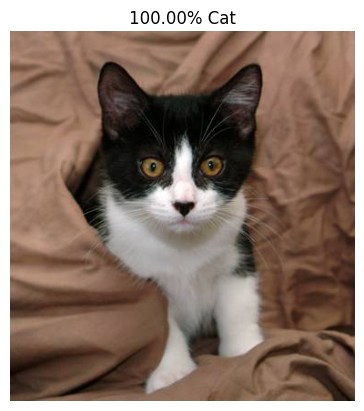

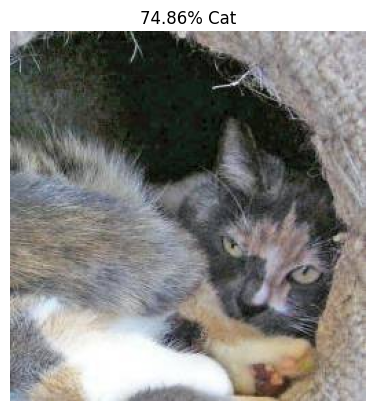

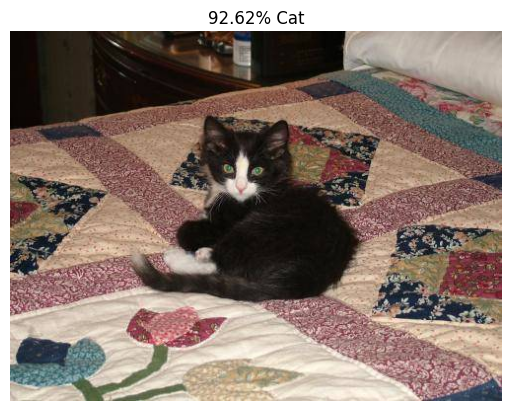

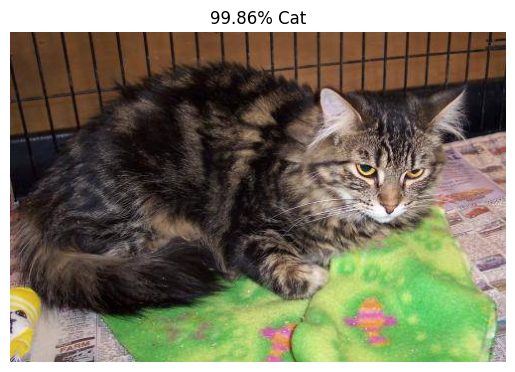

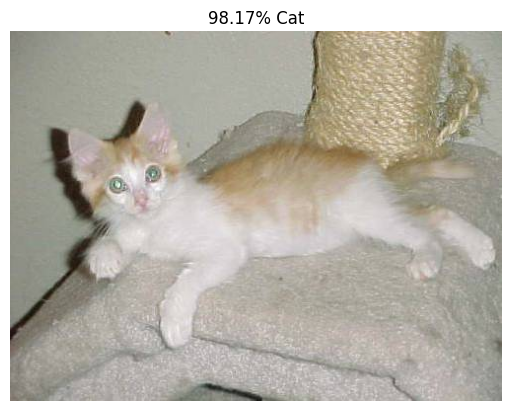

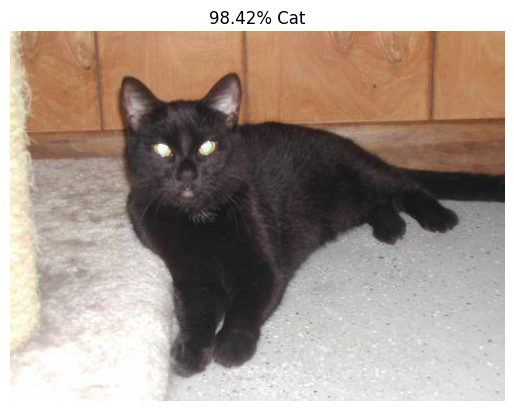

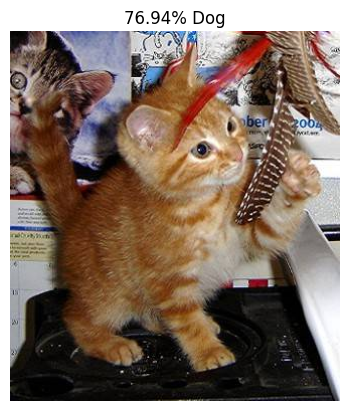

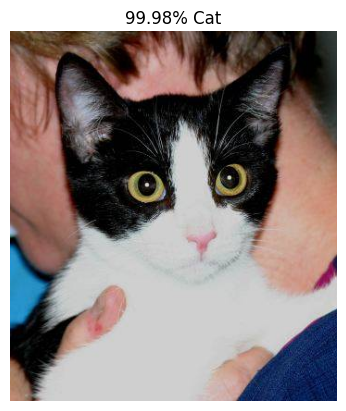

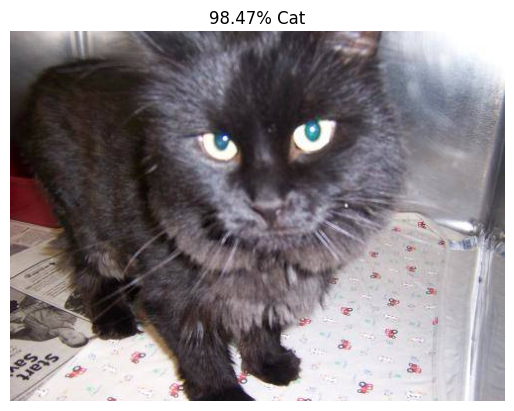

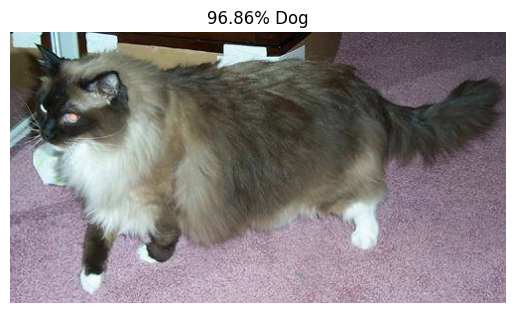

In [26]:
for index, probability in list(enumerate(probabilities))[:10]:
    image_path = test_data_dir + "/" + test_generator.filenames[index]
    image = mpimg.imread(image_path)
    plt.imshow(image)

    if probability > 0.5:
        plt.title(f"{probability[0] * 100:.2f}% Dog")
    else:
        plt.title(f"{(1 - probability[0]) * 100:.2f}% Cat")

    plt.axis("off")
    plt.show()